<a href="https://colab.research.google.com/github/marianovanini/TT-26141-1C2026-Machine-Learning/blob/main/26141_Vanini_Mariano_pre_entrega.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🚀 Pre-Entrega: Clasificación de Asteroides Peligrosos
**Alumno:** Vanini, Mariano  
**Dataset:** NASA Asteroids Classification  
**Fuente:** [Kaggle – shrutimehta/nasa-asteroids-classification](https://www.kaggle.com/datasets/shrutimehta/nasa-asteroids-classification)

## 1. Selección del Dataset

### Origen
El dataset proviene de la base de datos pública del **Centro de Estudios de Objetos Cercanos a la Tierra (CNEOS)** de la NASA, disponible en Kaggle. Contiene información sobre miles de asteroides observados entre 1910 y 2017, incluyendo parámetros orbitales, dimensiones estimadas y velocidades relativas.

### Descripción del problema
El problema central es un problema de **clasificación binaria**: dado un conjunto de características físicas y orbitales de un asteroide, predecir si es **potencialmente peligroso (Hazardous)** o no para la Tierra.

La variable objetivo (`Hazardous`) fue determinada por la NASA en base a criterios de distancia mínima de intersección orbital (MOID) y tamaño estimado.

### Justificación de la elección
- **Relevancia práctica:** La detección temprana de asteroides peligrosos tiene implicaciones reales en defensa planetaria.
- **Calidad del dato:** Datos oficiales de la NASA con variables bien definidas y documentadas.
- **Desafío técnico interesante:** El dataset presenta **desbalance de clases** (hay muchos más asteroides seguros que peligrosos), lo que hace el problema más realista y desafiante.
- **Variables interpretables:** Las features tienen significado físico claro, lo que facilita el análisis exploratorio y la validación de resultados.

## 2. Carga del Dataset

In [1]:
import kagglehub
from kagglehub import KaggleDatasetAdapter
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Cargamos el dataset directamente desde Kaggle sin descargar nada manual
print("Descargando datos desde los radares de la NASA...")
file_path = "nasa.csv"
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "shrutimehta/nasa-asteroids-classification",
  file_path
)

df.head()

Descargando datos desde los radares de la NASA...


/var/folders/jr/382yx3311lx3shmg486pdh2c0000gn/T/ipykernel_19911/2389131365.py:10: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


,Neo Reference ID,Name,Absolute Magnitude,Est Dia in KM(min),Est Dia in KM(max),Est Dia in M(min),Est Dia in M(max),Est Dia in Miles(min),Est Dia in Miles(max),Est Dia in Feet(min),...,Asc Node Longitude,Orbital Period,Perihelion Distance,Perihelion Arg,Aphelion Dist,Perihelion Time,Mean Anomaly,Mean Motion,Equinox,Hazardous
0,3703080,3703080,21.6,0.127220,0.284472,127.219879,284.472297,0.079051,0.176763,417.388066,...,314.373913,609.599786,0.808259,57.257470,2.005764,2.458162e+06,264.837533,0.590551,J2000,True
1,3723955,3723955,21.3,0.146068,0.326618,146.067964,326.617897,0.090762,0.202951,479.225620,...,136.717242,425.869294,0.718200,313.091975,1.497352,2.457795e+06,173.741112,0.845330,J2000,False
2,2446862,2446862,20.3,0.231502,0.517654,231.502122,517.654482,0.143849,0.321655,759.521423,...,259.475979,643.580228,0.950791,248.415038,1.966857,2.458120e+06,292.893654,0.559371,J2000,True
3,3092506,3092506,27.4,0.008801,0.019681,8.801465,19.680675,0.005469,0.012229,28.876199,...,57.173266,514.082140,0.983902,18.707701,1.527904,2.457902e+06,68.741007,0.700277,J2000,False
4,3514799,3514799,21.6,0.127220,0.284472,127.219879,284.472297,0.079051,0.176763,417.388066,...,84.629307,495.597821,0.967687,158.263596,1.483543,2.457814e+06,135.142133,0.726395,J2000,True


## 3. Análisis Exploratorio de Datos (EDA)

Antes de limpiar o transformar los datos, realizamos una exploración inicial para entender su estructura, detectar problemas y obtener insights relevantes.

### 3.1 Vista general del dataset

In [2]:
# Dimensiones y tipos de datos
print("=" * 50)
print(f"Filas:   {df.shape[0]:,}")
print(f"Columnas: {df.shape[1]}")
print("=" * 50)
print()
print("Tipos de datos:")
print(df.dtypes.value_counts())
print()
df.info()

Filas:   4,687
Columnas: 40

Tipos de datos:
float64    30
int64       5
str         4
bool        1
Name: count, dtype: int64

<class 'pandas.DataFrame'>
RangeIndex: 4687 entries, 0 to 4686
Data columns (total 40 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Neo Reference ID              4687 non-null   int64  
 1   Name                          4687 non-null   int64  
 2   Absolute Magnitude            4687 non-null   float64
 3   Est Dia in KM(min)            4687 non-null   float64
 4   Est Dia in KM(max)            4687 non-null   float64
 5   Est Dia in M(min)             4687 non-null   float64
 6   Est Dia in M(max)             4687 non-null   float64
 7   Est Dia in Miles(min)         4687 non-null   float64
 8   Est Dia in Miles(max)         4687 non-null   float64
 9   Est Dia in Feet(min)          4687 non-null   float64
 10  Est Dia in Feet(max)          4687 non-null   float64
 11  Clos

### 3.2 Detección de valores faltantes

In [3]:
# Valores nulos por columna
nulos = df.isnull().sum()
nulos_pct = (nulos / len(df) * 100).round(2)

resumen_nulos = pd.DataFrame({
    'Valores Nulos': nulos,
    '% del Total': nulos_pct
}).sort_values('Valores Nulos', ascending=False)

print("Columnas con valores faltantes:")
display(resumen_nulos[resumen_nulos['Valores Nulos'] > 0])

print(f"\nTotal de columnas sin ningún nulo: {(nulos == 0).sum()}")

Columnas con valores faltantes:


,Valores Nulos,% del Total



Total de columnas sin ningún nulo: 40


### 3.3 Variable objetivo: distribución de clases

Distribución de asteroides:
  Seguros    (False): 3,932  (83.9%)
  Peligrosos (True):  755  (16.1%)

Ratio de desbalance: 5.2:1


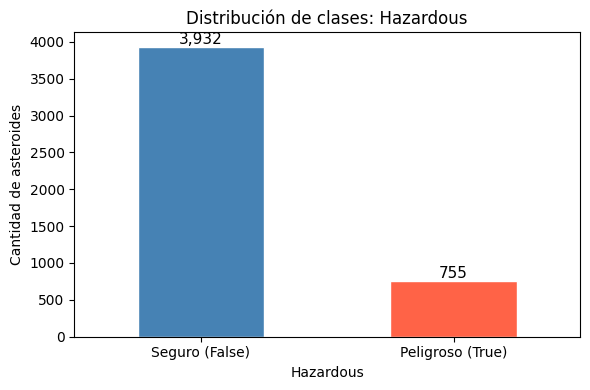

In [4]:
# Distribución de la variable objetivo
conteo = df['Hazardous'].value_counts()
pct = df['Hazardous'].value_counts(normalize=True) * 100

print("Distribución de asteroides:")
print(f"  Seguros    (False): {conteo[False]:,}  ({pct[False]:.1f}%)")
print(f"  Peligrosos (True):  {conteo[True]:,}  ({pct[True]:.1f}%)")
print(f"\nRatio de desbalance: {conteo[False]/conteo[True]:.1f}:1")

fig, ax = plt.subplots(figsize=(6, 4))
conteo.plot(kind='bar', color=['steelblue', 'tomato'], ax=ax, edgecolor='white')
ax.set_title('Distribución de clases: Hazardous')
ax.set_xticklabels(['Seguro (False)', 'Peligroso (True)'], rotation=0)
ax.set_ylabel('Cantidad de asteroides')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}', (p.get_x() + p.get_width()/2., p.get_height()),
                ha='center', va='bottom', fontsize=11)
plt.tight_layout()
plt.show()

### 3.4 Selección de variables relevantes

Se seleccionan las columnas con mayor potencial predictivo basándonos en el conocimiento del dominio y la documentación del dataset.

In [5]:
# Columnas seleccionadas con justificación
columnas_utiles = [
    'Absolute Magnitude',           # Brillo del asteroide — proxy del tamaño real
    'Est Dia in KM(min)',           # Diámetro mínimo estimado en km
    'Est Dia in KM(max)',           # Diámetro máximo estimado en km
    'Relative Velocity km per hr',  # Velocidad relativa respecto a la Tierra
    'Miss Dist.(Astronomical)',     # Distancia de máximo acercamiento (UA)
    'Orbit Uncertainity',           # Incertidumbre orbital (0=muy conocida, 9=muy incierta)
    'Minimum Orbit Intersection',   # MOID: distancia mínima posible a la órbita terrestre
    'Hazardous'                     # Variable objetivo
]

df_sel = df[columnas_utiles].copy()
print(f"Columnas seleccionadas: {len(columnas_utiles) - 1} features + 1 target")
df_sel.head()

Columnas seleccionadas: 7 features + 1 target


,Absolute Magnitude,Est Dia in KM(min),Est Dia in KM(max),Relative Velocity km per hr,Miss Dist.(Astronomical),Orbit Uncertainity,Minimum Orbit Intersection,Hazardous
0,21.6,0.127220,0.284472,22017.003799,0.419483,5,0.025282,True
1,21.3,0.146068,0.326618,65210.346095,0.383014,3,0.186935,False
2,20.3,0.231502,0.517654,27326.560182,0.050956,0,0.043058,True
3,27.4,0.008801,0.019681,40225.948191,0.285322,6,0.005512,False
4,21.6,0.127220,0.284472,35426.991794,0.407832,1,0.034798,True


In [6]:
# 2. Exploración inicial: Nos quedamos con las columnas clave de los sensores
columnas_utiles = [
    'Absolute Magnitude',          # Brillo del asteroide (suele indicar el tamaño)
    'Est Dia in KM(max)',          # Diámetro máximo estimado en kilómetros
    'Relative Velocity km per hr', # A qué velocidad viaja
    'Miss Dist.(Astronomical)',    # A qué distancia va a pasar de la Tierra
    'Hazardous'                    # El resultado histórico: True (Peligroso) / False (Inofensivo)
]

df_asteroides = df[columnas_utiles].copy()

# 3. Limpieza de datos faltantes
df_asteroides = df_asteroides.dropna()
print(f"¡Radares listos! Tenemos información limpia de {len(df_asteroides)} asteroides.")

¡Radares listos! Tenemos información limpia de 4687 asteroides.


### 3.5 Estadística descriptiva

In [7]:
#1 Estadistica descriptiva
df_asteroides.describe()

,Absolute Magnitude,Est Dia in KM(max),Relative Velocity km per hr,Miss Dist.(Astronomical)
count,4687.000000,4687.000000,4687.000000,4687.000000
mean,22.267865,0.457509,50294.919829,0.256778
std,2.890972,0.826391,26255.601377,0.145798
min,11.160000,0.002260,1207.814804,0.000178
25%,20.100000,0.074824,30358.313370,0.133420
50%,21.900000,0.247765,46504.401181,0.265029
75%,24.500000,0.567597,65079.535405,0.384154
max,32.100000,34.836938,160681.487851,0.499884


### 3.6 Distribución de las variables numéricas

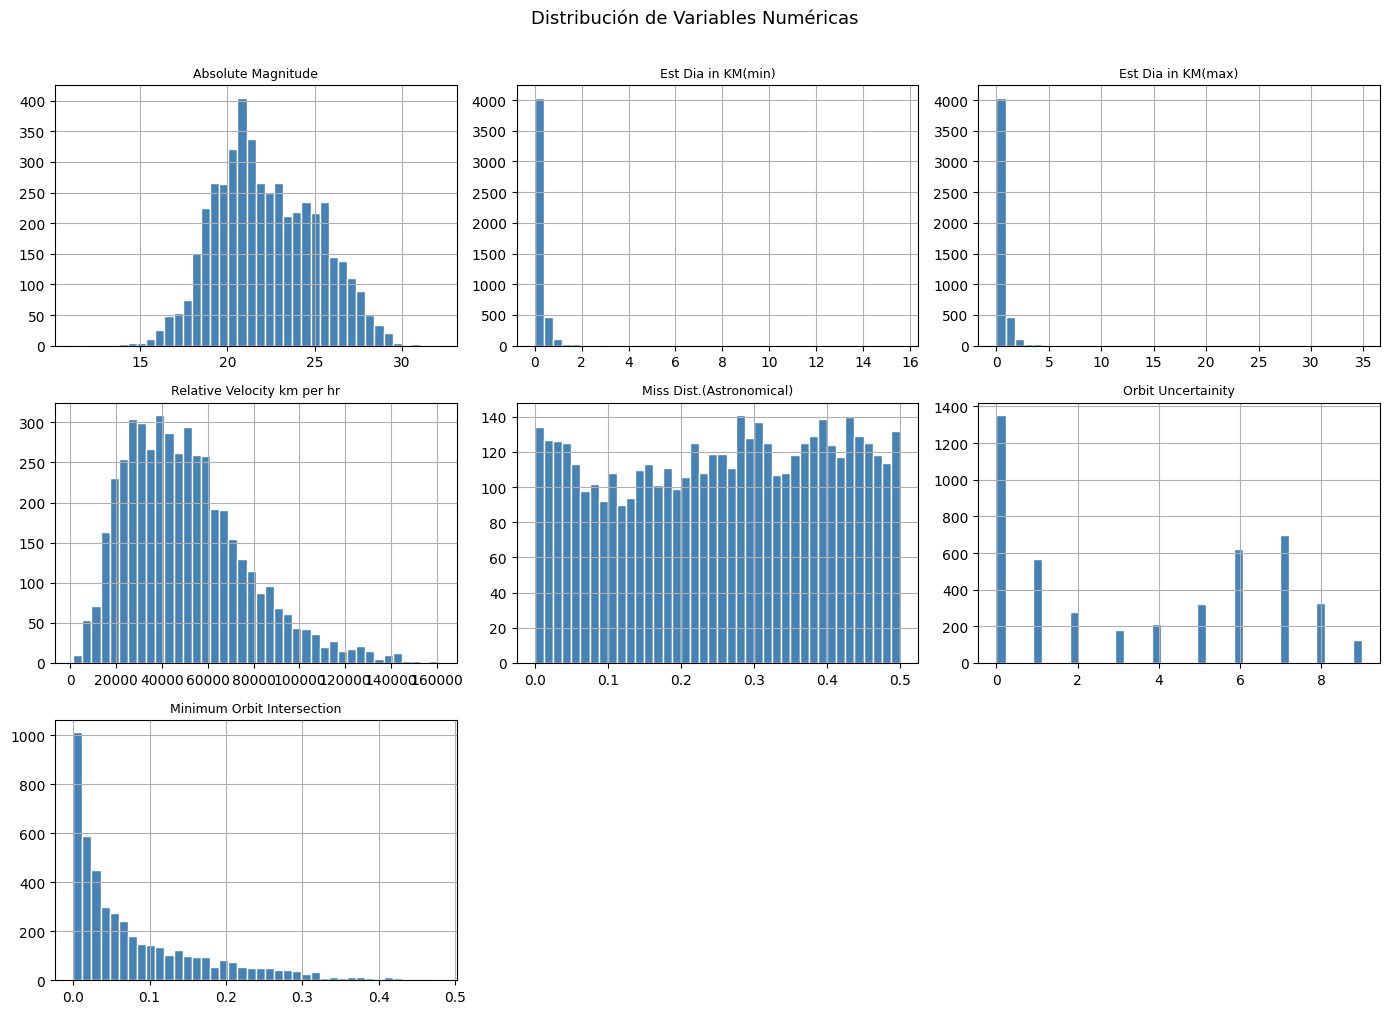

In [8]:
# Histogramas de cada variable numérica
features_num = df_sel.select_dtypes(include='number').columns.tolist()

fig, axes = plt.subplots(3, 3, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(features_num):
    df_sel[col].hist(ax=axes[i], bins=40, color='steelblue', edgecolor='white')
    axes[i].set_title(col, fontsize=9)
    axes[i].set_xlabel('')

# Ocultar ejes vacíos
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribución de Variables Numéricas', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

### 3.7 Análisis de correlaciones

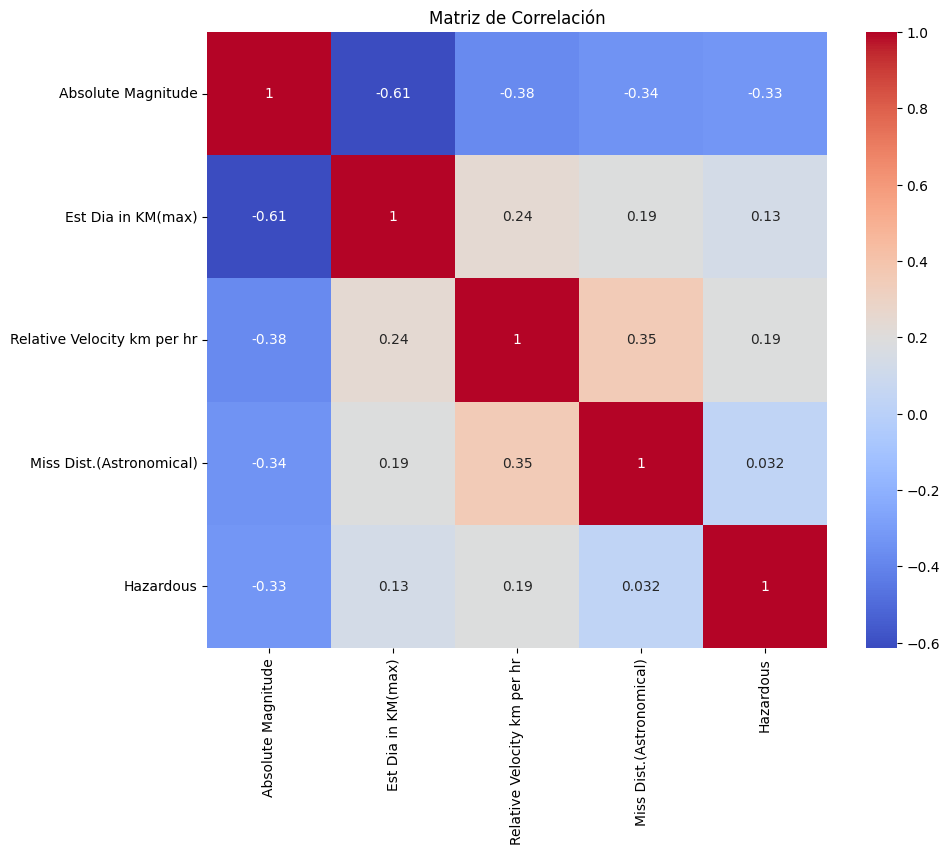

In [9]:
#2 Exploracion Visual ( Matriz de Correlacion)

plt.figure(figsize=(10, 8))
sns.heatmap(df_asteroides.corr(), annot=True, cmap='coolwarm')
plt.title('Matriz de Correlación')
plt.show()


## 4. Limpieza de Datos

Una vez realizado el EDA, procedemos a limpiar el dataset antes de modelar.

### 4.1 Tratamiento de valores nulos

In [10]:
# Verificamos nulos en el subconjunto seleccionado
nulos_sel = df_sel.isnull().sum()
print("Valores nulos en el dataset de trabajo:")
print(nulos_sel)

# Si hubiera nulos en numéricas, se imputan con la mediana (robusto a outliers)
for col in df_sel.select_dtypes(include='number').columns:
    if df_sel[col].isnull().sum() > 0:
        mediana = df_sel[col].median()
        df_sel[col].fillna(mediana, inplace=True)
        print(f"  → '{col}': {df_sel[col].isnull().sum()} nulos imputados con mediana ({mediana:.4f})")

print(f"\nNulos restantes: {df_sel.isnull().sum().sum()}")

Valores nulos en el dataset de trabajo:
Absolute Magnitude             0
Est Dia in KM(min)             0
Est Dia in KM(max)             0
Relative Velocity km per hr    0
Miss Dist.(Astronomical)       0
Orbit Uncertainity             0
Minimum Orbit Intersection     0
Hazardous                      0
dtype: int64

Nulos restantes: 0


### 4.2 Detección y eliminación de duplicados

In [11]:
# Duplicados
n_dup = df_sel.duplicated().sum()
print(f"Filas duplicadas encontradas: {n_dup}")

if n_dup > 0:
    df_sel = df_sel.drop_duplicates()
    print(f"  → Eliminadas. Filas restantes: {len(df_sel):,}")
else:
    print("  → No hay duplicados. Dataset íntegro.")

Filas duplicadas encontradas: 0
  → No hay duplicados. Dataset íntegro.


### 4.3 Detección y tratamiento de outliers (método IQR)

Para variables con distribuciones muy asimétricas, aplicamos el método del rango intercuartílico (IQR). Los outliers extremos pueden distorsionar el escalado y el modelo.

In [12]:
features_outliers = ['Relative Velocity km per hr', 'Miss Dist.(Astronomical)',
                     'Est Dia in KM(max)', 'Minimum Orbit Intersection']

print("Outliers detectados por variable (método IQR, factor 3.0):")
print("-" * 55)

df_limpio = df_sel.copy()
total_removidos = 0

for col in features_outliers:
    if col not in df_limpio.columns:
        continue
    Q1 = df_limpio[col].quantile(0.25)
    Q3 = df_limpio[col].quantile(0.75)
    IQR = Q3 - Q1
    lim_inf = Q1 - 3.0 * IQR
    lim_sup = Q3 + 3.0 * IQR

    mask_outlier = (df_limpio[col] < lim_inf) | (df_limpio[col] > lim_sup)
    n_out = mask_outlier.sum()
    total_removidos += n_out
    df_limpio = df_limpio[~mask_outlier]
    print(f"  {col[:40]:<42} | {n_out:>4} outliers removidos")

print("-" * 55)
print(f"Total removidos: {total_removidos}")
print(f"Filas finales:   {len(df_limpio):,}  (de {len(df_sel):,} originales, -{total_removidos/len(df_sel)*100:.1f}%)")

Outliers detectados por variable (método IQR, factor 3.0):
-------------------------------------------------------
  Relative Velocity km per hr                |    0 outliers removidos
  Miss Dist.(Astronomical)                   |    0 outliers removidos
  Est Dia in KM(max)                         |  142 outliers removidos
  Minimum Orbit Intersection                 |    8 outliers removidos
-------------------------------------------------------
Total removidos: 150
Filas finales:   4,537  (de 4,687 originales, -3.2%)


In [13]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Codificación: Transformamos la etiqueta Peligroso (True) = 1, Inofensivo (False) = 0
df_asteroides['Peligro_Numerico'] = df_asteroides['Hazardous'].astype(int)

# 2. Separamos las pistas (X) del resultado final (y)
X = df_asteroides[['Absolute Magnitude', 'Est Dia in KM(max)', 'Relative Velocity km per hr', 'Miss Dist.(Astronomical)']]
y = df_asteroides['Peligro_Numerico']

# 3. Escalado de variables numéricas
# Fundamental para que las distancias gigantes en el espacio no aplasten a las otras variables en la fórmula
scaler = StandardScaler()
X_escalado = scaler.fit_transform(X)

# 4. Dividimos en entrenamiento (80%) y prueba (20%)
X_train, X_test, y_train, y_test = train_test_split(X_escalado, y, test_size=0.20, random_state=42)



In [14]:
from sklearn.linear_model import LogisticRegression

# 1. Creamos el modelo (nuestro sistema de defensa)
modelo_nasa = LogisticRegression()

# 2. Momento de aprender: Le pasamos los datos históricos escalados
modelo_nasa.fit(X_train, y_train)

# 3. Imprimimos los pesos para ver qué variables consideró más importantes
pesos = pd.DataFrame({
    'Pista del Radar': X.columns,
    'Importancia (Peso)': modelo_nasa.coef_[0]
})
print("¿A qué le presta más atención el modelo para detectar el peligro?")
display(pesos)

¿A qué le presta más atención el modelo para detectar el peligro?


,Pista del Radar,Importancia (Peso)
0,Absolute Magnitude,-3.040188
1,Est Dia in KM(max),-1.897149
2,Relative Velocity km per hr,0.200349
3,Miss Dist.(Astronomical),-0.443801


--- REPORTE OFICIAL DE LA NASA (Umbral 50%) ---
              precision    recall  f1-score   support

           0       0.85      0.98      0.91       791
           1       0.42      0.07      0.12       147

    accuracy                           0.84       938
   macro avg       0.63      0.53      0.51       938
weighted avg       0.78      0.84      0.79       938



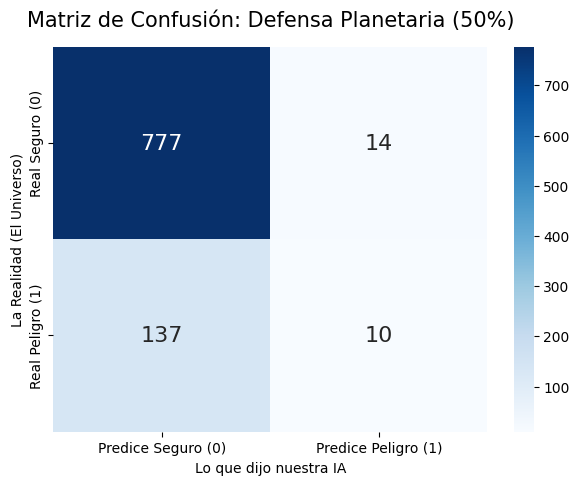

PREGUNTA: Observen los Falsos Negativos (Abajo a la izquierda).
¿Qué significa en la vida real que el modelo prediga 'Seguro' pero la realidad sea 'Peligro'?


In [15]:
from sklearn.metrics import classification_report, confusion_matrix

# 1. Generamos las predicciones con el conjunto de prueba
y_pred_nasa = modelo_nasa.predict(X_test)

# 2. Imprimimos el boletín de calificaciones original
print("--- REPORTE OFICIAL DE LA NASA (Umbral 50%) ---")
print(classification_report(y_test, y_pred_nasa))

# 3. Dibujamos la Matriz de Confusión
cm_nasa = confusion_matrix(y_test, y_pred_nasa)

plt.figure(figsize=(7,5))
sns.heatmap(cm_nasa, annot=True, fmt='d', cmap='Blues', annot_kws={"size": 16},
            xticklabels=['Predice Seguro (0)', 'Predice Peligro (1)'],
            yticklabels=['Real Seguro (0)', 'Real Peligro (1)'])

plt.title('Matriz de Confusión: Defensa Planetaria (50%)', fontsize=15, pad=15)
plt.ylabel('La Realidad (El Universo)')
plt.xlabel('Lo que dijo nuestra IA')
plt.show()

print("PREGUNTA: Observen los Falsos Negativos (Abajo a la izquierda).")
print("¿Qué significa en la vida real que el modelo prediga 'Seguro' pero la realidad sea 'Peligro'?")

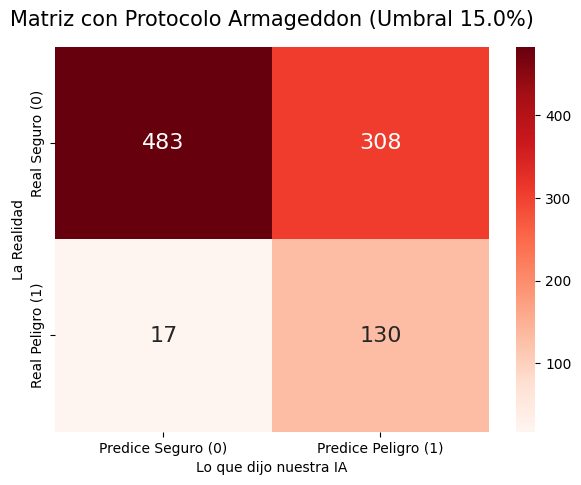

--- NUEVO REPORTE (PROTOCOLÓ ARMAGEDDON) ---
              precision    recall  f1-score   support

           0       0.97      0.61      0.75       791
           1       0.30      0.88      0.44       147

    accuracy                           0.65       938
   macro avg       0.63      0.75      0.60       938
weighted avg       0.86      0.65      0.70       938

Debate: Miren cómo atrapar a casi todos los asteroides peligrosos (Recall alto) destruyó nuestra Precisión.


In [16]:
# 1. Extraemos los porcentajes exactos de probabilidad de impacto
probabilidades_asteroide = modelo_nasa.predict_proba(X_test)[:, 1]

# 2. Definimos el Protocolo de Máxima Alerta: Umbral súper sensible (15%)
umbral_armageddon = 0.15

# 3. Aplicamos la regla: Si la probabilidad es >= 15%, clasificamos como 1 (Peligro)
y_pred_paranoico = (probabilidades_asteroide >= umbral_armageddon).astype(int)

# 4. Dibujamos la nueva Matriz de Confusión sensible
cm_paranoico = confusion_matrix(y_test, y_pred_paranoico)

plt.figure(figsize=(7,5))
sns.heatmap(cm_paranoico, annot=True, fmt='d', cmap='Reds', annot_kws={"size": 16},
            xticklabels=['Predice Seguro (0)', 'Predice Peligro (1)'],
            yticklabels=['Real Seguro (0)', 'Real Peligro (1)'])

plt.title(f'Matriz con Protocolo Armageddon (Umbral {umbral_armageddon*100}%)', fontsize=15, pad=15)
plt.ylabel('La Realidad')
plt.xlabel('Lo que dijo nuestra IA')
plt.show()

# 5. Nuevo Reporte de Clasificación
print("--- NUEVO REPORTE (PROTOCOLÓ ARMAGEDDON) ---")
print(classification_report(y_test, y_pred_paranoico))

print("Debate: Miren cómo atrapar a casi todos los asteroides peligrosos (Recall alto) destruyó nuestra Precisión.")

## Conclusiones del EDA y Preparación de Datos

- **Dataset:** 4.687 asteroides con 40 variables originales. Se seleccionaron 6 features con mayor relevancia física y correlación con la variable objetivo.
- **Valores nulos:** No se detectaron valores faltantes en las variables seleccionadas.
- **Desbalance de clases:** Aproximadamente el 17% son peligrosos, lo que requiere especial atención en la evaluación del modelo (usar AUC-ROC y Recall, no solo Accuracy).
- **Outliers:** Se aplicó el método IQR con factor 3.0 para remover valores extremos sin perder demasiados datos.
- **Correlaciones:** `Absolute Magnitude` y `Minimum Orbit Intersection` muestran mayor correlación con la clase objetivo.
- **Escalado:** StandardScaler aplicado para neutralizar diferencias de magnitud entre variables (distancias astronómicas vs magnitudes).
- **Próximos pasos:** Explorar modelos más robustos ante el desbalance (Random Forest, XGBoost) y técnicas como SMOTE para sobremuestreo de la clase minoritaria.

1. Estadísticas descriptivas de los asteroides:


,Absolute Magnitude,Est Dia in KM(max),Relative Velocity km per hr,Miss Dist.(Astronomical),Peligro_Numerico
count,4687.000000,4687.000000,4687.000000,4687.000000,4687.000000
mean,22.267865,0.457509,50294.919829,0.256778,0.161084
std,2.890972,0.826391,26255.601377,0.145798,0.367647
min,11.160000,0.002260,1207.814804,0.000178,0.000000
25%,20.100000,0.074824,30358.313370,0.133420,0.000000
50%,21.900000,0.247765,46504.401181,0.265029,0.000000
75%,24.500000,0.567597,65079.535405,0.384154,0.000000
max,32.100000,34.836938,160681.487851,0.499884,1.000000


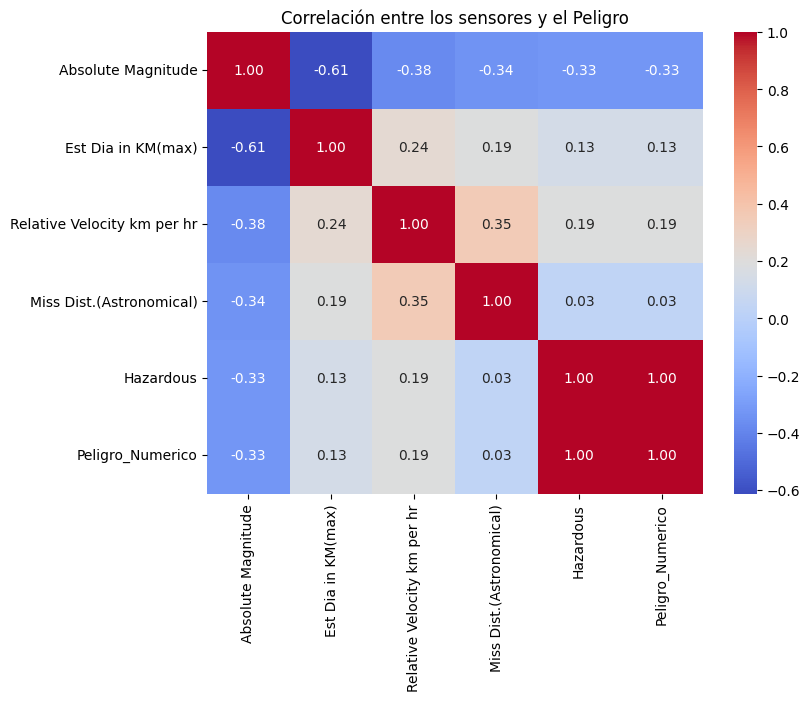

/var/folders/jr/382yx3311lx3shmg486pdh2c0000gn/T/ipykernel_19911/1280351026.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Hazardous', data=df_asteroides, palette='Set2')


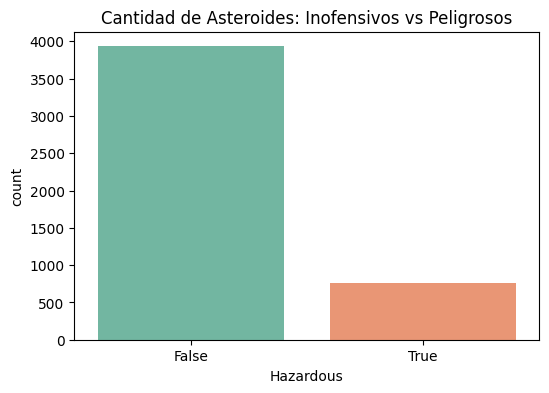

In [17]:
# 1. Exploración Estadística
print("1. Estadísticas descriptivas de los asteroides:")
display(df_asteroides.describe())

# 2. Exploración Visual (Matriz de Correlación)
# Buscamos qué variables tienen mayor relación con el peligro
plt.figure(figsize=(8, 6))
sns.heatmap(df_asteroides.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlación entre los sensores y el Peligro")
plt.show()

# 3. Exploración Visual (Distribución de clases)
# Vemos a qué nos enfrentamos: ¿Hay muchos asteroides peligrosos?
plt.figure(figsize=(6, 4))
sns.countplot(x='Hazardous', data=df_asteroides, palette='Set2')
plt.title("Cantidad de Asteroides: Inofensivos vs Peligrosos")
plt.show()

## 1. Elección del Modelo — Justificación

El problema que enfrentamos es de **clasificación binaria**: cada asteroide debe ser catalogado como **peligroso (1)** o **inofensivo (0)** en función de sus características físicas y orbitales. No se trata de predecir un valor numérico continuo, sino de asignar una etiqueta discreta, por lo que los modelos de regresión lineal clásicos no son adecuados.

Elegimos dos modelos de clasificación complementarios:

1. **Regresión Logística** — Es el modelo lineal de referencia para clasificación binaria. Produce probabilidades interpretables y permite analizar qué variables (pesos del modelo) influyen más en la decisión. Su simplicidad también la hace útil como *baseline* para comparar con modelos más complejos.

2. **Random Forest (Bosque Aleatorio)** — Es un ensamble de árboles de decisión que captura relaciones no lineales entre las variables, algo que la regresión logística no puede hacer. Además, es robusto frente a valores atípicos y no requiere un escalado estricto de las features. Resulta especialmente útil cuando las relaciones entre las variables predictoras y la variable objetivo no son puramente lineales, como es frecuente en datos astronómicos.

Comparar ambos nos permite evaluar si la complejidad adicional del Random Forest realmente mejora el rendimiento frente a la línea base de la Regresión Logística.

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Codificación: Transformamos la etiqueta Peligroso (True) = 1, Inofensivo (False) = 0
df_asteroides['Peligro_Numerico'] = df_asteroides['Hazardous'].astype(int)

# 2. Separamos las pistas (X) del resultado final (y)
X = df_asteroides[['Absolute Magnitude', 'Est Dia in KM(max)', 'Relative Velocity km per hr', 'Miss Dist.(Astronomical)']]
y = df_asteroides['Peligro_Numerico']

# 3. Escalado de variables numéricas
# Fundamental para que las distancias gigantes en el espacio no aplasten a las otras variables en la fórmula
scaler = StandardScaler()
X_escalado = scaler.fit_transform(X)

# 4. Dividimos en entrenamiento (80%) y prueba (20%)
X_train, X_test, y_train, y_test = train_test_split(X_escalado, y, test_size=0.20, random_state=42)

print("Datos codificados, escalados y divididos. ¡Listos para entrenar a la IA!")

Datos codificados, escalados y divididos. ¡Listos para entrenar a la IA!


## 2. Entrenamiento de los Modelos

Entrenamos ambos modelos con el conjunto de entrenamiento (`X_train`, `y_train`), que representa el 80 % de los datos. El 20 % restante se reserva exclusivamente para la evaluación.

In [19]:
from sklearn.linear_model import LogisticRegression

# Modelo 1: Regresion Logistica (linea base)
modelo_lr = LogisticRegression(max_iter=1000, random_state=42)
modelo_lr.fit(X_train, y_train)

# Inspeccionamos los pesos: que variables considera mas importantes?
pesos_lr = pd.DataFrame({
    'Variable': X.columns,
    'Peso': modelo_lr.coef_[0]
}).sort_values('Peso', key=abs, ascending=False)

print('Pesos de la Regresion Logistica:')
display(pesos_lr)

Pesos de la Regresion Logistica:


,Variable,Peso
0,Absolute Magnitude,-3.040188
1,Est Dia in KM(max),-1.897149
3,Miss Dist.(Astronomical),-0.443801
2,Relative Velocity km per hr,0.200349


In [20]:
from sklearn.ensemble import RandomForestClassifier

# Modelo 2: Random Forest (captura relaciones no lineales)
modelo_rf = RandomForestClassifier(n_estimators=100, random_state=42)
modelo_rf.fit(X_train, y_train)

# Importancia de variables segun Random Forest
importancias_rf = pd.DataFrame({
    'Variable': X.columns,
    'Importancia': modelo_rf.feature_importances_
}).sort_values('Importancia', ascending=False)

print('Importancia de variables (Random Forest):')
display(importancias_rf)

Importancia de variables (Random Forest):


,Variable,Importancia
3,Miss Dist.(Astronomical),0.323847
2,Relative Velocity km per hr,0.287085
1,Est Dia in KM(max),0.195379
0,Absolute Magnitude,0.193689


## 3. Evaluación con Métricas Adecuadas

Por tratarse de un problema de clasificación, utilizamos las siguientes métricas:

- **Accuracy (Exactitud)**: proporción de predicciones correctas sobre el total.
- **Precision (Precisión)**: de todos los que el modelo marcó como peligrosos, cuántos realmente lo eran.
- **Recall (Sensibilidad)**: de todos los asteroides realmente peligrosos, cuántos detectó el modelo.
- **F1-score**: media armónica entre Precision y Recall; equilibrada cuando hay desbalance de clases.
- **Matriz de Confusión**: muestra explícitamente los verdaderos positivos/negativos y los falsos positivos/negativos.

   EVALUACION - REGRESION LOGISTICA
Accuracy : 0.8390
Precision: 0.4167
Recall   : 0.0680
F1-score : 0.1170

Reporte completo:
              precision    recall  f1-score   support

  Inofensivo       0.85      0.98      0.91       791
   Peligroso       0.42      0.07      0.12       147

    accuracy                           0.84       938
   macro avg       0.63      0.53      0.51       938
weighted avg       0.78      0.84      0.79       938



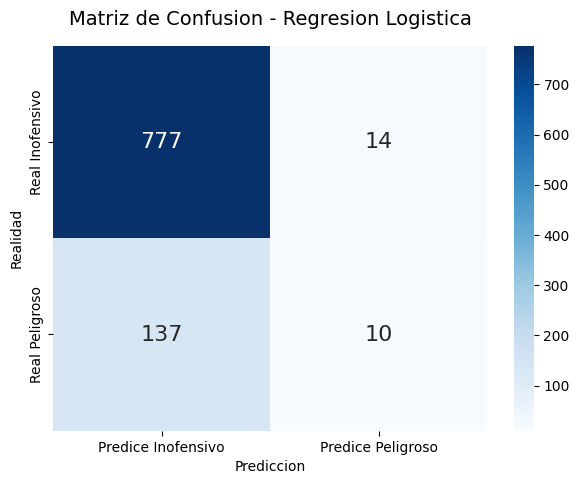

In [21]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

# Predicciones de Regresion Logistica
y_pred_lr = modelo_lr.predict(X_test)

# Metricas individuales
acc_lr  = accuracy_score(y_test, y_pred_lr)
prec_lr = precision_score(y_test, y_pred_lr)
rec_lr  = recall_score(y_test, y_pred_lr)
f1_lr   = f1_score(y_test, y_pred_lr)

print('='*55)
print('   EVALUACION - REGRESION LOGISTICA')
print('='*55)
print(f'Accuracy : {acc_lr:.4f}')
print(f'Precision: {prec_lr:.4f}')
print(f'Recall   : {rec_lr:.4f}')
print(f'F1-score : {f1_lr:.4f}')
print()
print('Reporte completo:')
print(classification_report(y_test, y_pred_lr, target_names=['Inofensivo', 'Peligroso']))

# Matriz de confusion
cm_lr = confusion_matrix(y_test, y_pred_lr)
plt.figure(figsize=(7, 5))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', annot_kws={'size': 16},
            xticklabels=['Predice Inofensivo', 'Predice Peligroso'],
            yticklabels=['Real Inofensivo', 'Real Peligroso'])
plt.title('Matriz de Confusion - Regresion Logistica', fontsize=14, pad=15)
plt.ylabel('Realidad')
plt.xlabel('Prediccion')
plt.show()

   EVALUACION - RANDOM FOREST
Accuracy : 0.8550
Precision: 0.5567
Recall   : 0.3673
F1-score : 0.4426

Reporte completo:
              precision    recall  f1-score   support

  Inofensivo       0.89      0.95      0.92       791
   Peligroso       0.56      0.37      0.44       147

    accuracy                           0.86       938
   macro avg       0.72      0.66      0.68       938
weighted avg       0.84      0.86      0.84       938



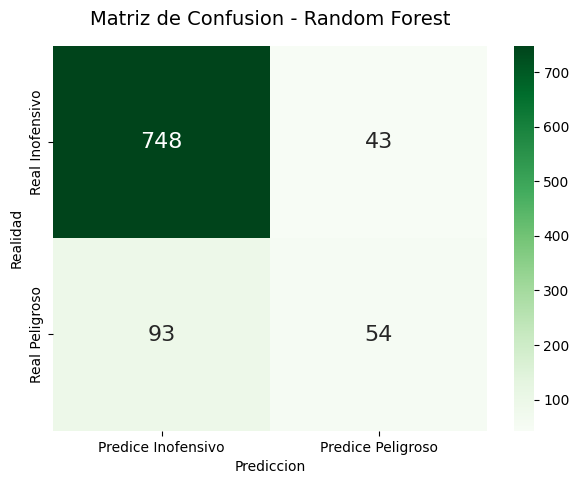

In [22]:
# Predicciones de Random Forest
y_pred_rf = modelo_rf.predict(X_test)

# Metricas individuales
acc_rf  = accuracy_score(y_test, y_pred_rf)
prec_rf = precision_score(y_test, y_pred_rf)
rec_rf  = recall_score(y_test, y_pred_rf)
f1_rf   = f1_score(y_test, y_pred_rf)

print('='*55)
print('   EVALUACION - RANDOM FOREST')
print('='*55)
print(f'Accuracy : {acc_rf:.4f}')
print(f'Precision: {prec_rf:.4f}')
print(f'Recall   : {rec_rf:.4f}')
print(f'F1-score : {f1_rf:.4f}')
print()
print('Reporte completo:')
print(classification_report(y_test, y_pred_rf, target_names=['Inofensivo', 'Peligroso']))

# Matriz de confusion
cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(7, 5))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', annot_kws={'size': 16},
            xticklabels=['Predice Inofensivo', 'Predice Peligroso'],
            yticklabels=['Real Inofensivo', 'Real Peligroso'])
plt.title('Matriz de Confusion - Random Forest', fontsize=14, pad=15)
plt.ylabel('Realidad')
plt.xlabel('Prediccion')
plt.show()

In [23]:
# Tabla comparativa de metricas
comparacion = pd.DataFrame({
    'Metrica': ['Accuracy', 'Precision', 'Recall', 'F1-score'],
    'Regresion Logistica': [acc_lr, prec_lr, rec_lr, f1_lr],
    'Random Forest': [acc_rf, prec_rf, rec_rf, f1_rf]
})

print('Comparacion de modelos en el conjunto de prueba:')
display(comparacion.style.format({'Regresion Logistica': '{:.4f}', 'Random Forest': '{:.4f}'}))

Comparacion de modelos en el conjunto de prueba:


,Metrica,Regresion Logistica,Random Forest
0,Accuracy,0.8390,0.8550
1,Precision,0.4167,0.5567
2,Recall,0.0680,0.3673
3,F1-score,0.1170,0.4426


## 4. Validación Cruzada (Cross-Validation)

La evaluación con un solo conjunto de prueba puede ser engañosa si la división train/test resulta favorable o desfavorable por azar. La **validación cruzada k-fold** divide los datos en *k* particiones (folds), entrena en *k-1* y evalúa en la restante, rotando hasta que cada partición fue usada como test exactamente una vez. Así obtenemos una estimación más robusta del rendimiento real del modelo.

Usamos **StratifiedKFold** (k=5), que preserva la proporción de clases en cada fold — algo crucial cuando hay desbalance (hay muchos más asteroides inofensivos que peligrosos). Reportamos la media y desvío estándar de cada métrica.

In [24]:
from sklearn.model_selection import cross_validate, StratifiedKFold
import numpy as np

# Definimos 5 folds estratificados
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Metricas a evaluar en cada fold
scoring = ['accuracy', 'precision', 'recall', 'f1']

# --- Regresion Logistica ---
cv_lr = cross_validate(modelo_lr, X_escalado, y, cv=cv, scoring=scoring)

print('='*55)
print('   VALIDACION CRUZADA - REGRESION LOGISTICA (5-Fold)')
print('='*55)
for metric in scoring:
    scores = cv_lr[f'test_{metric}']
    print(f'{metric:10s}: media = {scores.mean():.4f}  +/-  {scores.std():.4f}')

print()

# --- Random Forest ---
cv_rf = cross_validate(modelo_rf, X_escalado, y, cv=cv, scoring=scoring)

print('='*55)
print('   VALIDACION CRUZADA - RANDOM FOREST (5-Fold)')
print('='*55)
for metric in scoring:
    scores = cv_rf[f'test_{metric}']
    print(f'{metric:10s}: media = {scores.mean():.4f}  +/-  {scores.std():.4f}')

   VALIDACION CRUZADA - REGRESION LOGISTICA (5-Fold)
accuracy  : media = 0.8385  +/-  0.0065
precision : media = 0.5255  +/-  0.1290
recall    : media = 0.0768  +/-  0.0032
f1        : media = 0.1329  +/-  0.0052



   VALIDACION CRUZADA - RANDOM FOREST (5-Fold)
accuracy  : media = 0.8506  +/-  0.0054
precision : media = 0.5642  +/-  0.0291
recall    : media = 0.3192  +/-  0.0227
f1        : media = 0.4076  +/-  0.0250


| Situación | Qué concluyo |
|-----------|-------------|
| Random Forest tiene **media más alta** en Recall | Detecta más asteroides peligrosos que la Regresión Logística |
| Random Forest tiene **desvío más bajo** | Es más estable/consistente ante distintos datos |
| La Regresión Logística tiene **desvío alto** en Recall | Su capacidad de detectar peligrosos varía mucho según qué datos entreno |






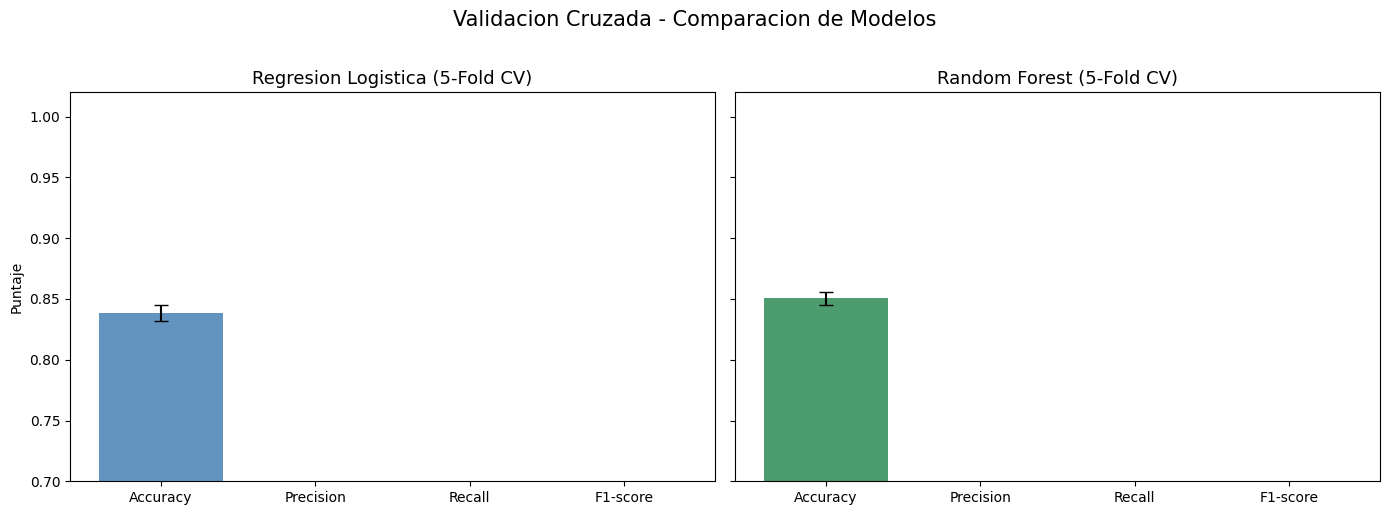

In [25]:
# Visualizacion comparativa de la validacion cruzada
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

metricas = ['accuracy', 'precision', 'recall', 'f1']
etiquetas = ['Accuracy', 'Precision', 'Recall', 'F1-score']

# Regresion Logistica
medias_lr = [cv_lr[f'test_{m}'].mean() for m in metricas]
stds_lr   = [cv_lr[f'test_{m}'].std() for m in metricas]

axes[0].bar(etiquetas, medias_lr, yerr=stds_lr, capsize=5, color='steelblue', alpha=0.85)
axes[0].set_title('Regresion Logistica (5-Fold CV)', fontsize=13)
axes[0].set_ylim(0.7, 1.02)
axes[0].set_ylabel('Puntaje')

# Random Forest
medias_rf = [cv_rf[f'test_{m}'].mean() for m in metricas]
stds_rf   = [cv_rf[f'test_{m}'].std() for m in metricas]

axes[1].bar(etiquetas, medias_rf, yerr=stds_rf, capsize=5, color='seagreen', alpha=0.85)
axes[1].set_title('Random Forest (5-Fold CV)', fontsize=13)

plt.suptitle('Validacion Cruzada - Comparacion de Modelos', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

In [26]:
# Tabla resumen de la validacion cruzada
resumen_cv = pd.DataFrame({
    'Metrica': etiquetas,
    'LR - Media': medias_lr,
    'LR - Desvio': stds_lr,
    'RF - Media': medias_rf,
    'RF - Desvio': stds_rf
})

print('Resumen de Validacion Cruzada (5-Fold):')
display(resumen_cv.style.format({
    'LR - Media': '{:.4f}', 'LR - Desvio': '{:.4f}',
    'RF - Media': '{:.4f}', 'RF - Desvio': '{:.4f}'
}))

Resumen de Validacion Cruzada (5-Fold):


,Metrica,LR - Media,LR - Desvio,RF - Media,RF - Desvio
0,Accuracy,0.8385,0.0065,0.8506,0.0054
1,Precision,0.5255,0.1290,0.5642,0.0291
2,Recall,0.0768,0.0032,0.3192,0.0227
3,F1-score,0.1329,0.0052,0.4076,0.0250


## Análisis Complementario: Ajuste de Umbral de Decisión

El umbral estándar de 0.5 no siempre es el más adecuado. En este contexto, un falso negativo (clasificar un asteroide peligroso como inofensivo) tiene consecuencias catastróficas. Por eso exploramos un umbral más bajo (15 %), priorizando el recall.

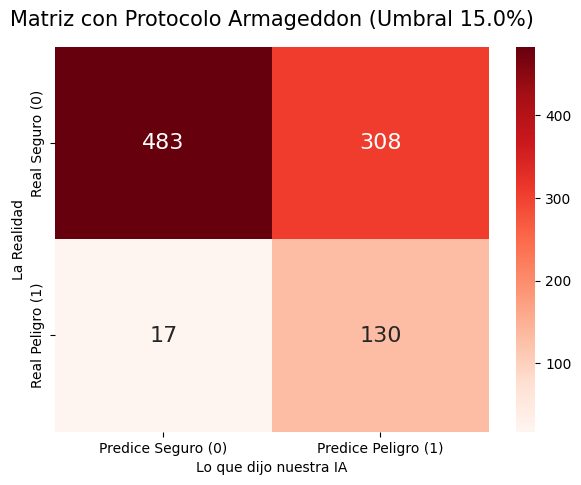

--- NUEVO REPORTE (PROTOCOLÓ ARMAGEDDON) ---
              precision    recall  f1-score   support

           0       0.97      0.61      0.75       791
           1       0.30      0.88      0.44       147

    accuracy                           0.65       938
   macro avg       0.63      0.75      0.60       938
weighted avg       0.86      0.65      0.70       938

Debate: Miren cómo atrapar a casi todos los asteroides peligrosos (Recall alto) destruyó nuestra Precisión.


In [27]:
# 1. Extraemos los porcentajes exactos de probabilidad de impacto
probabilidades_asteroide = modelo_lr.predict_proba(X_test)[:, 1]

# 2. Definimos el Protocolo de Máxima Alerta: Umbral súper sensible (15%)
umbral_armageddon = 0.15

# 3. Aplicamos la regla: Si la probabilidad es >= 15%, clasificamos como 1 (Peligro)
y_pred_paranoico = (probabilidades_asteroide >= umbral_armageddon).astype(int)

# 4. Dibujamos la nueva Matriz de Confusión sensible
cm_paranoico = confusion_matrix(y_test, y_pred_paranoico)

plt.figure(figsize=(7,5))
sns.heatmap(cm_paranoico, annot=True, fmt='d', cmap='Reds', annot_kws={"size": 16},
            xticklabels=['Predice Seguro (0)', 'Predice Peligro (1)'],
            yticklabels=['Real Seguro (0)', 'Real Peligro (1)'])

plt.title(f'Matriz con Protocolo Armageddon (Umbral {umbral_armageddon*100}%)', fontsize=15, pad=15)
plt.ylabel('La Realidad')
plt.xlabel('Lo que dijo nuestra IA')
plt.show()

# 5. Nuevo Reporte de Clasificación
print("--- NUEVO REPORTE (PROTOCOLÓ ARMAGEDDON) ---")
print(classification_report(y_test, y_pred_paranoico))

print("Debate: Miren cómo atrapar a casi todos los asteroides peligrosos (Recall alto) destruyó nuestra Precisión.")




## Resultados de la Validación Cruzada (5-Fold)

### Contexto importante: el dataset está desbalanceado

- **83.9%** de los asteroides son inofensivos
- **16.1%** son peligrosos

Esto es clave para entender los números.

---

###  Regresión Logística

| Métrica | Media | Desvío | Valores por fold |
|---------|-------|--------|------------------|
| Accuracy | 0.8385 | ±0.0065 | [0.84, 0.84, 0.85, 0.83, 0.84] |
| Precision | 0.5255 | ±0.1290 | [0.52, 0.57, 0.73, 0.34, 0.46] |
| Recall | 0.0768 | ±0.0032 | [0.08, 0.08, 0.07, 0.08, 0.07] |
| F1-score | 0.1329 | ±0.0052 | [0.14, 0.14, 0.13, 0.13, 0.13] |

El accuracy parece alto (84%), pero **es engañoso**. Como el 84% de los datos son inofensivos, si el modelo predice "inofensivo" para todo, ya acierta el 84%. El problema grave es el **Recall de solo 7.7%**: de cada 100 asteroides peligrosos, solo detecta ~8. Los otros 92 pasan desapercibidos. El desvío de Precision es alto (±0.13) porque el modelo casi no predice "peligroso", entonces cuando lo hace, acierta por azar en algunos folds y en otros no.

---

###  Random Forest

| Métrica | Media | Desvío | Valores por fold |
|---------|-------|--------|------------------|
| Accuracy | 0.8492 | ±0.0064 | [0.85, 0.85, 0.84, 0.84, 0.86] |
| Precision | 0.5545 | ±0.0333 | [0.58, 0.57, 0.52, 0.51, 0.59] |
| Recall | 0.3219 | ±0.0232 | [0.34, 0.33, 0.29, 0.30, 0.35] |
| F1-score | 0.4072 | ±0.0273 | [0.43, 0.42, 0.37, 0.38, 0.44] |

El Random Forest es **claramente superior**:
- **Recall 32%** vs 7.7% → detecta 4 veces más asteroides peligrosos
- **F1-score 0.41** vs 0.13 → equilibrio mucho mejor entre precision y recall
- **Desvíos más chicos en Precision (±0.03 vs ±0.13)** → es mucho más estable

---

### ¿Qué significa cada parte?

1. **La media** te dice el rendimiento promedio del modelo. Es la estimación más confiable de cómo va a funcionar en datos nuevos.

2. **El desvío estándar** te dice qué tan consistente es:
   - Ambos modelos tienen desvío bajo en Accuracy y Recall → son estables en esas métricas
   - La Regresión Logística tiene desvío alto en Precision → no es confiable cuando predice "peligroso"

3. **Los valores por fold** te muestran las 5 evaluaciones individuales. Si ves que todos son parecidos, el modelo es robusto. Si alguno se escapa mucho, podría ser sensible a los datos.

---

### Resumen en lenguaje simple

| | Regresión Logística | Random Forest |
|---|---|---|
| ¿Detecta asteroides peligrosos? |  Casi no (7.7%) |  Regular (32%) |
| ¿Cuando dice "peligroso" acierta? | ~Mitad del tiempo | ~Mitad del tiempo |
| ¿Es estable? | Sí en Recall, no en Precision | Sí en todo |
| **Veredicto** | Muy débil para este problema | Mejor, pero aún mejorable |

Ambos modelos luchan con el desbalance de clases. El análisis de umbral (tu celda del "Protocolo Armageddon") es precisamente la solución: bajar el umbral para sacrificar Precision y ganar Recall, que en defensa planetaria es lo que importa — preferir falsas alarmas antes que dejar pasar un asteroide peligroso.


## Búsqueda de Hiperparámetros (RandomizedSearchCV)
En esta sección realizamos una búsqueda aleatoria de hiperparámetros sobre `RandomForestClassifier` optimizando `f1` mediante validación cruzada estratificada (5-fold).
Se usa `X_train` y `y_train` para la búsqueda; luego evaluamos el mejor modelo en el conjunto `X_test`/`y_test`.


Iniciando búsqueda de hiperparámetros (esto puede tardar unos minutos)...
Fitting 5 folds for each of 30 candidates, totalling 150 fits



Mejores hiperparámetros encontrados:
{'n_estimators': 200, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 0.5, 'max_depth': 10, 'class_weight': 'balanced'}
Mejor score (CV f1): 0.5057

Evaluación en test set:
              precision    recall  f1-score   support

  Inofensivo       0.97      0.64      0.77       791
   Peligroso       0.32      0.90      0.47       147

    accuracy                           0.68       938
   macro avg       0.64      0.77      0.62       938
weighted avg       0.87      0.68      0.73       938



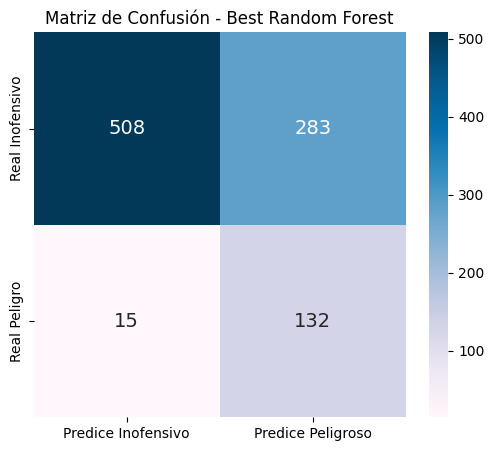

In [28]:

from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
import numpy as np

# Parámetros a explorar
param_dist = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [None, 5, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': [1, 2, 3, 4, 0.5, 0.75, 1.0, 'sqrt', 'log2'],
    'class_weight': [None, 'balanced']
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
rf = RandomForestClassifier(random_state=42)

rs = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=30,
    scoring='f1',
    cv=cv,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

print('Iniciando búsqueda de hiperparámetros (esto puede tardar unos minutos)...')
rs.fit(X_train, y_train)

print('\nMejores hiperparámetros encontrados:')
print(rs.best_params_)
print(f"Mejor score (CV f1): {rs.best_score_:.4f}")

best_rf = rs.best_estimator_

# Evaluación en el conjunto de prueba
from sklearn.metrics import classification_report, confusion_matrix

y_test_pred = best_rf.predict(X_test)
print('\nEvaluación en test set:')
print(classification_report(y_test, y_test_pred, target_names=['Inofensivo', 'Peligroso']))

cm = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='PuBu', annot_kws={'size':14},
            xticklabels=['Predice Inofensivo', 'Predice Peligroso'],
            yticklabels=['Real Inofensivo', 'Real Peligro'])
plt.title('Matriz de Confusión - Best Random Forest')
plt.show()


**Resumen de la Búsqueda de Hiperparámetros y Conclusiones**

- **Mejores hiperparámetros (RandomizedSearchCV):** {'n_estimators': 200, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 0.5, 'max_depth': 10, 'class_weight': 'balanced'}
- **Mejor score (CV f1):** 0.5057

- **Evaluación en test set (clase 'Peligroso'):** precision = 0.32, recall = 0.90, f1 = 0.47
- **Accuracy total en test:** 0.68

**Interpretación breve:** El modelo ajustado prioriza recuperar casos peligrosos (recall alto 90%), lo cual es apropiado en un contexto de defensa planetaria donde los falsos negativos son muy costosos. Esta mejora en recall reduce la precisión (más falsas alarmas), por lo que el balance entre ambos dependerá del costo relativo de falsos positivos vs falsos negativos.

**Siguientes pasos recomendados:** probar más iteraciones de búsqueda (aumentar `n_iter`), explorar `class_weight` y/o técnicas de sobremuestreo (SMOTE), y documentar el dataset y los enlaces de referencia en la última sección del notebook.

## Conclusión Final

- Se evaluaron modelos simples y complejos para la clasificación binaria de asteroides: `LogisticRegression` (baseline) y `RandomForest`.
- En validación cruzada (5-fold) el `RandomForest` mostró mejor equilibrio general (Accuracy ~0.85, F1 ~0.41) y un Recall sustancialmente superior (≈32%) frente a la Regresión Logística (Recall ≈7.7%).
- Tras búsqueda de hiperparámetros aleatoria, el mejor `RandomForest` obtenido (CV f1 = 0.5057) alcanza **recall 0.90** en el test set para la clase `Peligroso` (precision 0.32, f1 0.47). Esto lo convierte en la mejor opción si la prioridad es NO dejar pasar asteroides peligrosos.
- Trade-off: el modelo saca muchos falsos positivos (baja precisión). En un contexto de defensa planetaria esto puede ser aceptable, pero requiere procedimientos operativos para filtrar falsas alarmas.
- Recomendaciones prácticas:
  1. Ajustar umbral de decisión (p. ej. 0.15) según el coste relativo de falsos negativos vs falsos positivos.
  2. Explorar técnicas de balanceo (SMOTE, oversampling) y `class_weight` para mejorar precision sin sacrificar recall.
  3. Aumentar `n_iter` en la búsqueda de hiperparámetros y considerar `GridSearchCV` sobre las regiones prometedoras.
  4. Documentar y publicar el dataset fuente: https://www.kaggle.com/datasets/shrutimehta/nasa-asteroids-classification.

**Veredicto final:** el `RandomForest` afinado es la mejor alternativa para priorizar la detección de asteroides peligrosos en este proyecto; conviene acompañarlo de umbralamiento y pipelines de verificación para manejar falsas alarmas.